# Task 2 – Unsupervised Learning

This notebook is the core of the Task 2 report. The task is to discover latent structure in `dungeon_sensorstats.csv` with no supervision during fitting. The hidden `species` column is kept only for post-hoc interpretation and external validation.

The motivation is exploratory: when labels are missing or deliberately withheld, unsupervised learning helps us inspect whether the sensor measurements form meaningful groups or reveal anomalies. That is useful in the robotics / perception setting because it tells us whether the feature space itself contains structure worth trusting.

## Algorithm Choice and Rationale

`K-Means` is a compact centroid baseline. After standardization, it is a good first test when clusters are expected to be roughly compact and roughly spherical. It is fast, interpretable, and easy to profile through cluster means [1].

`Gaussian Mixture Model (GMM)` is the probabilistic counterpart. It supports soft assignments and covariance structure, so it can model overlap and non-spherical cluster geometry better than K-Means [2].

For visualization, `PCA` gives a quick linear overview of the dominant directions of variance, while `UMAP` often shows local neighborhoods and cluster borders more clearly. Using both is a useful way to avoid over-reading a single projection [3], [4].

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'task2_unsupervised' / 'src' / 'common.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the AIR repository root.')


PROJECT_ROOT = find_project_root()
TASK2_ROOT = PROJECT_ROOT / 'task2_unsupervised'
SRC_DIR = TASK2_ROOT / 'src'
CONFIGS_DIR = TASK2_ROOT / 'configs'
OUTPUTS_DIR = TASK2_ROOT / 'outputs'
BRIBE_OUTPUTS_DIR = TASK2_ROOT / 'outputs_bribe'
DATA_PATH = PROJECT_ROOT / 'dungeon_sensorstats.csv'

sys.path.insert(0, str(SRC_DIR))

from common import (  # noqa: E402
    build_cluster_profile,
    build_preprocessed_data,
    ensure_dirs,
    evaluate_internal_metrics,
    evaluate_optional_external_metrics,
    load_preprocessed_artifacts,
    load_raw_dataset,
    now_stamp,
    read_json,
    select_best_candidate,
    set_global_seed,
    software_versions,
    write_json,
)

set_global_seed(42)
ensure_dirs(OUTPUTS_DIR / 'tables', OUTPUTS_DIR / 'figures', OUTPUTS_DIR / 'logs')

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path:    {DATA_PATH}')
print(f'Outputs:      {OUTPUTS_DIR}')

Project root: /Users/ziyanlei/Desktop/AIR
Data path:    /Users/ziyanlei/Desktop/AIR/dungeon_sensorstats.csv
Outputs:      /Users/ziyanlei/Desktop/AIR/task2_unsupervised/outputs


In [2]:
def load_json(path: Path) -> Dict[str, Any]:
    return json.loads(path.read_text(encoding='utf-8'))


kmeans_cfg = load_json(CONFIGS_DIR / 'kmeans.json')
gmm_cfg = load_json(CONFIGS_DIR / 'gmm.json')
config_df = pd.DataFrame([
    {'method': 'kmeans', **kmeans_cfg},
    {'method': 'gmm', **gmm_cfg},
])
print('Key configuration parameters:')
display(config_df)

raw_df = load_raw_dataset(DATA_PATH)
preprocessed = build_preprocessed_data(raw_df, include_bribe=False)
print(f'Raw shape: {raw_df.shape}')
print(f'Preprocessed feature shape: {preprocessed.scaled_features.shape}')
print(f'Feature columns: {preprocessed.feature_columns}')

Key configuration parameters:


,method,k_range,n_init,max_iter,algorithm,selection_rule,components_range,covariance_type,reg_covar
0,kmeans,"[2, 3, 4, 5, 6, 7, 8]",20,500,lloyd,"sort by silhouette desc, davies_bouldin asc, c...",NaN,NaN,NaN
1,gmm,NaN,10,300,NaN,"sort by silhouette desc, davies_bouldin asc, c...","[2, 3, 4, 5, 6, 7, 8]",full,0.000001


Raw shape: (10000, 11)
Preprocessed feature shape: (10000, 9)
Feature columns: ['stench', 'sound', 'intelligence', 'weight', 'height', 'strength', 'heat', 'magic', 'flight']


In [3]:
saved = load_preprocessed_artifacts(OUTPUTS_DIR / 'tables', 'preprocessed_main')
preproc_summary = pd.read_csv(OUTPUTS_DIR / 'tables' / 'preprocessed_main_preprocessing_summary.csv')
missing_summary = pd.read_csv(OUTPUTS_DIR / 'tables' / 'preprocessed_main_missing_summary.csv')
feature_table = pd.read_csv(OUTPUTS_DIR / 'tables' / 'preprocessed_main_feature_columns.csv')

display(preproc_summary)
display(missing_summary)
display(feature_table)

assert list(preprocessed.feature_columns) == list(saved.feature_columns)
assert np.allclose(preprocessed.scaled_features.to_numpy(), saved.scaled_features.to_numpy())
print('Shared preprocessing artifact reproduced successfully.')

,artifact_prefix,n_rows,n_features,include_bribe,preprocessing_version,created_at
0,preprocessed_main,10000,9,False,v1_median_impute_continuous_mode_binary_standa...,2026-04-14T14:24:20


,feature,missing_count
0,stench,25
1,sound,30
2,intelligence,28
3,weight,34
4,height,34
5,strength,28
6,heat,41
7,magic,0
8,flight,0


,feature,feature_type
0,stench,continuous
1,sound,continuous
2,intelligence,continuous
3,weight,continuous
4,height,continuous
5,strength,continuous
6,heat,continuous
7,magic,binary
8,flight,binary


Shared preprocessing artifact reproduced successfully.


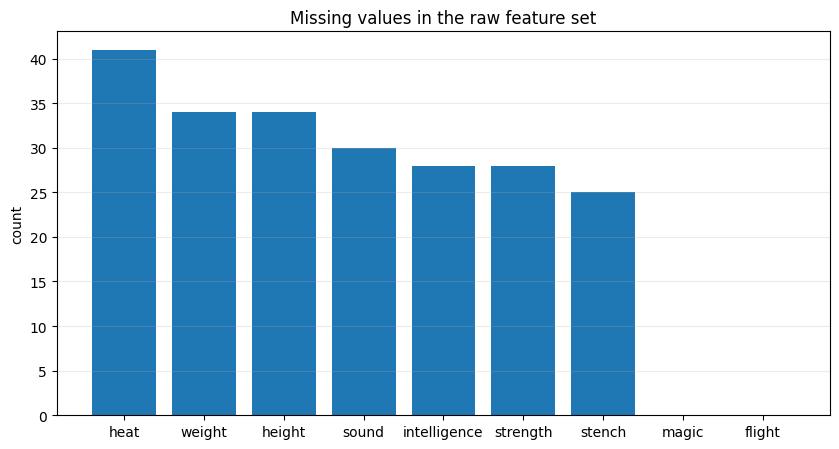

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
miss = missing_summary.sort_values('missing_count', ascending=False)
ax.bar(miss['feature'], miss['missing_count'], color='tab:blue')
ax.set_title('Missing values in the raw feature set')
ax.set_ylabel('count')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_missing_values.png', dpi=200, bbox_inches='tight')
plt.show()

## Core Implementation Excerpt

The next cell shows the essential preprocessing and clustering logic. The goal is not to duplicate every helper in `src`, but to make the algorithmic choices visible in the notebook itself.

In [5]:
# Essential preprocessing and clustering logic, adapted from src/preprocess_data.py,
# src/train_kmeans.py, and src/train_gmm.py.

BASE_CONTINUOUS_FEATURES = ['stench', 'sound', 'intelligence', 'weight', 'height', 'strength', 'heat']
OPTIONAL_CONTINUOUS_FEATURES = ['bribe']
BINARY_FEATURES = ['magic', 'flight']


def evaluate_cluster_run(X: np.ndarray, labels: np.ndarray, y_true: np.ndarray) -> Dict[str, float]:
    return {
        'silhouette': float(silhouette_score(X, labels)),
        'davies_bouldin': float(davies_bouldin_score(X, labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X, labels)),
        'ari': float(adjusted_rand_score(y_true, labels)),
        'nmi': float(normalized_mutual_info_score(y_true, labels)),
    }


def scan_kmeans_candidates(X: np.ndarray, y_true: np.ndarray, seed: int, k_range: List[int], n_init: int, max_iter: int):
    rows, assignments, centers = [], {}, {}
    for k in k_range:
        start = time.perf_counter()
        model = KMeans(n_clusters=k, random_state=seed, n_init=n_init, max_iter=max_iter, algorithm='lloyd')
        labels = model.fit_predict(X)
        rows.append({'method': 'kmeans', 'seed': seed, 'n_clusters': k, **evaluate_cluster_run(X, labels, y_true), 'fit_seconds': float(time.perf_counter() - start)})
        assignments[k] = labels
        centers[k] = model.cluster_centers_
    metrics_df = pd.DataFrame(rows).sort_values('n_clusters').reset_index(drop=True)
    best_row = select_best_candidate(metrics_df)
    return metrics_df, best_row, assignments, centers


def scan_gmm_candidates(X: np.ndarray, y_true: np.ndarray, seed: int, components_range: List[int], covariance_type: str, n_init: int, max_iter: int, reg_covar: float):
    rows, assignments, means, covdiag = [], {}, {}, {}
    for k in components_range:
        start = time.perf_counter()
        model = GaussianMixture(n_components=k, covariance_type=covariance_type, random_state=seed, n_init=n_init, max_iter=max_iter, reg_covar=reg_covar)
        labels = model.fit_predict(X)
        probs = model.predict_proba(X)
        rows.append({
            'method': 'gmm',
            'seed': seed,
            'n_clusters': k,
            **evaluate_cluster_run(X, labels, y_true),
            'avg_max_posterior': float(probs.max(axis=1).mean()),
            'fit_seconds': float(time.perf_counter() - start),
        })
        assignments[k] = labels
        means[k] = model.means_
        covariances = np.asarray(model.covariances_)
        if covariance_type == 'full':
            covdiag[k] = np.stack([np.diag(covariances[idx]) for idx in range(k)], axis=0)
        elif covariance_type == 'tied':
            covdiag[k] = np.tile(np.diag(covariances)[np.newaxis, :], (k, 1))
        elif covariance_type == 'diag':
            covdiag[k] = covariances
        else:
            covdiag[k] = np.tile(covariances.reshape(-1, 1), (1, X.shape[1]))
    metrics_df = pd.DataFrame(rows).sort_values('n_clusters').reset_index(drop=True)
    best_row = select_best_candidate(metrics_df)
    return metrics_df, best_row, assignments, means, covdiag

In [6]:
# Run the seed-42 experiment from scratch.
X = preprocessed.scaled_features.to_numpy(dtype=float)
y_true = preprocessed.species_labels.to_numpy(dtype=str)

k_range = [int(v) for v in kmeans_cfg['k_range']]
component_range = [int(v) for v in gmm_cfg['components_range']]

kmeans_metrics, kmeans_best, kmeans_assignments, kmeans_centers = scan_kmeans_candidates(
    X=X,
    y_true=y_true,
    seed=42,
    k_range=k_range,
    n_init=int(kmeans_cfg.get('n_init', 10)),
    max_iter=int(kmeans_cfg.get('max_iter', 300)),
)

gmm_metrics, gmm_best, gmm_assignments, gmm_means, gmm_covdiag = scan_gmm_candidates(
    X=X,
    y_true=y_true,
    seed=42,
    components_range=component_range,
    covariance_type=str(gmm_cfg.get('covariance_type', 'full')),
    n_init=int(gmm_cfg.get('n_init', 1)),
    max_iter=int(gmm_cfg.get('max_iter', 200)),
    reg_covar=float(gmm_cfg.get('reg_covar', 1e-6)),
)

display(kmeans_metrics)
display(gmm_metrics)
print(pd.DataFrame([kmeans_best.to_dict(), gmm_best.to_dict()]).to_string(index=False))

,method,seed,n_clusters,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,fit_seconds
0,kmeans,42,2,0.458746,0.865191,11494.906563,0.360524,0.558031,0.811725
1,kmeans,42,3,0.441597,0.916180,10278.256293,0.606756,0.769410,0.617657
2,kmeans,42,4,0.552429,0.645540,13231.483546,0.768514,0.872471,0.601313
3,kmeans,42,5,0.557785,0.735717,16845.798894,0.985178,0.979462,0.550139
4,kmeans,42,6,0.567111,0.710041,16317.844396,0.946035,0.956407,0.532932
5,kmeans,42,7,0.530754,0.845542,15411.559860,0.877615,0.918385,0.559933
6,kmeans,42,8,0.471349,0.937740,14581.810495,0.806190,0.884178,0.571074


,method,seed,n_clusters,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,avg_max_posterior,fit_seconds
0,gmm,42,2,0.457624,0.872865,11426.378732,0.374379,0.587052,0.999841,0.760091
1,gmm,42,3,0.435920,0.980540,9779.904816,0.613457,0.787079,0.999815,0.696404
2,gmm,42,4,0.554667,0.644376,13050.312267,0.779803,0.900667,0.999996,0.690606
3,gmm,42,5,0.557080,0.738137,16726.066486,0.994511,0.990662,0.999745,0.639028
4,gmm,42,6,0.566270,0.713580,16193.071270,0.946883,0.958154,0.999961,0.755081
5,gmm,42,7,0.529710,0.848298,15280.892692,0.878559,0.920085,0.999961,0.857274
6,gmm,42,8,0.446011,1.009419,14010.809114,0.807327,0.885868,0.973744,0.952362


method  seed  n_clusters  silhouette  davies_bouldin  calinski_harabasz      ari      nmi  fit_seconds  avg_max_posterior
kmeans    42           6    0.567111        0.710041       16317.844396 0.946035 0.956407     0.532932                NaN
   gmm    42           6    0.566270        0.713580       16193.071270 0.946883 0.958154     0.755081           0.999961


## Design Choices and Parameter Tuning

The project compares candidates over the shared range `k/components = 2..8` and uses the same selection rule for both methods: Silhouette descending, Davies-Bouldin ascending, and Calinski-Harabasz descending. That keeps the comparison fair.

The notebook also reports two views: `method_best`, where each method picks its own best cluster count, and `fixed_same_k`, where both methods are compared at `k=5` to align with the five known species.

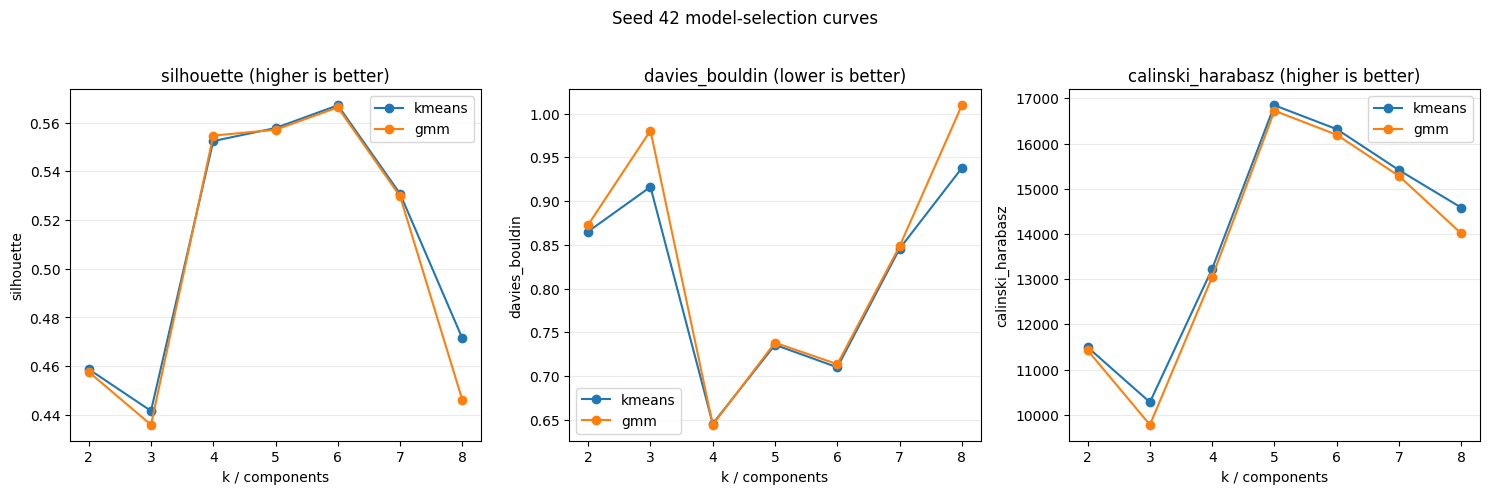

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, metric, note in [
    (axes[0], 'silhouette', 'higher is better'),
    (axes[1], 'davies_bouldin', 'lower is better'),
    (axes[2], 'calinski_harabasz', 'higher is better'),
]:
    ax.plot(kmeans_metrics['n_clusters'], kmeans_metrics[metric], marker='o', label='kmeans')
    ax.plot(gmm_metrics['n_clusters'], gmm_metrics[metric], marker='o', label='gmm')
    ax.set_xlabel('k / components')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} ({note})')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

fig.suptitle('Seed 42 model-selection curves', y=1.02)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_selection_curves_seed42.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
selected_kmeans = int(kmeans_best['n_clusters'])
selected_gmm = int(gmm_best['n_clusters'])

compare_seed42 = pd.DataFrame([
    {'view': 'method_best', 'method': 'kmeans', 'selected_clusters': selected_kmeans, **kmeans_metrics.loc[kmeans_metrics['n_clusters'] == selected_kmeans].iloc[0].to_dict()},
    {'view': 'method_best', 'method': 'gmm', 'selected_clusters': selected_gmm, **gmm_metrics.loc[gmm_metrics['n_clusters'] == selected_gmm].iloc[0].to_dict()},
    {'view': 'fixed_same_k', 'method': 'kmeans', 'selected_clusters': 5, **kmeans_metrics.loc[kmeans_metrics['n_clusters'] == 5].iloc[0].to_dict()},
    {'view': 'fixed_same_k', 'method': 'gmm', 'selected_clusters': 5, **gmm_metrics.loc[gmm_metrics['n_clusters'] == 5].iloc[0].to_dict()},
])
compare_seed42 = compare_seed42[['view', 'method', 'selected_clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'ari', 'nmi', 'fit_seconds']]
display(compare_seed42)

,view,method,selected_clusters,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,fit_seconds
0,method_best,kmeans,6,0.567111,0.710041,16317.844396,0.946035,0.956407,0.532932
1,method_best,gmm,6,0.566270,0.713580,16193.071270,0.946883,0.958154,0.755081
2,fixed_same_k,kmeans,5,0.557785,0.735717,16845.798894,0.985178,0.979462,0.550139
3,fixed_same_k,gmm,5,0.557080,0.738137,16726.066486,0.994511,0.990662,0.639028


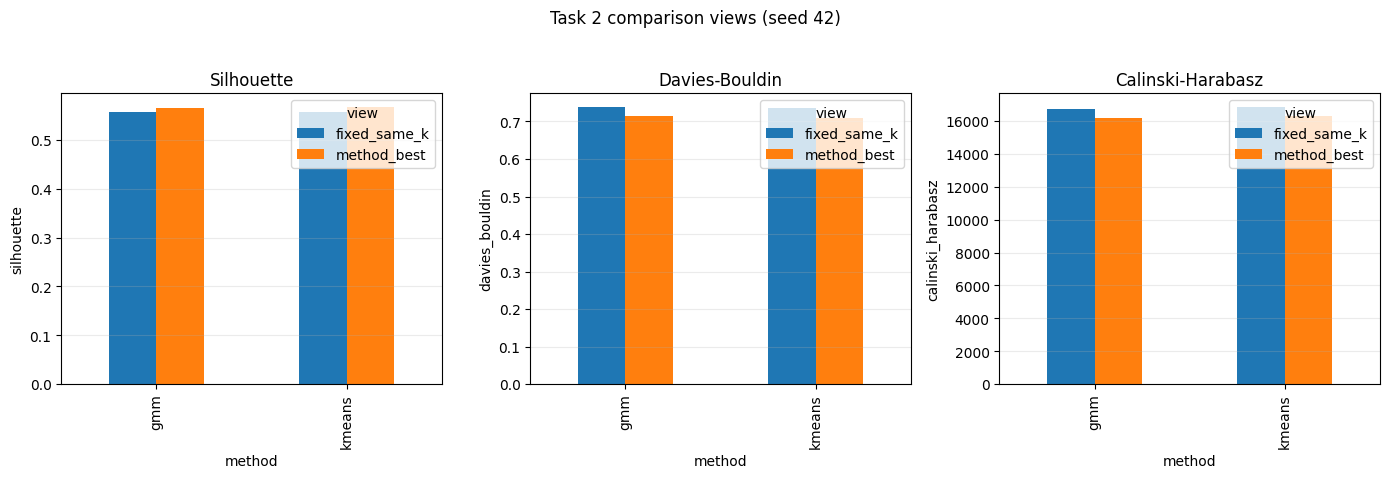

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, metric, title in [
    (axes[0], 'silhouette', 'Silhouette'),
    (axes[1], 'davies_bouldin', 'Davies-Bouldin'),
    (axes[2], 'calinski_harabasz', 'Calinski-Harabasz'),
]:
    pivot = compare_seed42.pivot(index='method', columns='view', values=metric)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('method')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Task 2 comparison views (seed 42)', y=1.03)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_compare_seed42.png', dpi=200, bbox_inches='tight')
plt.show()

In [10]:
# Species labels are only used after fitting, to interpret the clusters.
kmeans_assign_df = pd.DataFrame({'species': y_true, 'cluster': kmeans_assignments[selected_kmeans]})
gmm_assign_df = pd.DataFrame({'species': y_true, 'cluster': gmm_assignments[selected_gmm]})

kmeans_ct = pd.crosstab(kmeans_assign_df['cluster'], kmeans_assign_df['species'])
gmm_ct = pd.crosstab(gmm_assign_df['cluster'], gmm_assign_df['species'])

display(kmeans_ct)
display(gmm_ct)

kmeans_profile = build_cluster_profile(preprocessed.imputed_features, kmeans_assignments[selected_kmeans], 'kmeans', 42, selected_kmeans, top_n=3)
gmm_profile = build_cluster_profile(preprocessed.imputed_features, gmm_assignments[selected_gmm], 'gmm', 42, selected_gmm, top_n=3)

display(kmeans_profile[['cluster', 'size', 'ratio', 'top_features_by_abs_z']])
display(gmm_profile[['cluster', 'size', 'ratio', 'top_features_by_abs_z']])

species,halfling,human,lizard,orc,winged_rat
cluster,,,,,
0,1990,7,0,0,0
1,0,0,1992,0,0
2,0,0,3,0,2000
3,0,0,0,2000,0
4,0,500,0,0,0
5,10,1493,5,0,0


species,halfling,human,lizard,orc,winged_rat
cluster,,,,,
0,1988,0,0,0,0
1,0,0,1991,0,0
2,0,0,4,0,2000
3,0,0,0,2000,0
4,0,500,0,0,0
5,12,1500,5,0,0


,cluster,size,ratio,top_features_by_abs_z
0,0,1997,0.1997,strength:-1.66; weight:-1.57; height:-1.48
1,1,1992,0.1992,heat:-1.54; weight:0.53; height:0.50
2,2,2003,0.2003,flight:1.54; heat:1.25; intelligence:-0.88
3,3,2000,0.2000,sound:1.69; stench:1.39; intelligence:-1.31
4,4,500,0.0500,magic:4.36; intelligence:2.09; stench:-0.97
5,5,1508,0.1508,stench:-0.81; flight:-0.65; intelligence:0.62


,cluster,size,ratio,top_features_by_abs_z
0,0,1988,0.1988,strength:-1.67; weight:-1.57; height:-1.47
1,1,1991,0.1991,heat:-1.54; weight:0.53; height:0.50
2,2,2004,0.2004,flight:1.54; heat:1.25; intelligence:-0.88
3,3,2000,0.2000,sound:1.69; stench:1.39; intelligence:-1.31
4,4,500,0.0500,magic:4.36; intelligence:2.09; stench:-0.97
5,5,1517,0.1517,stench:-0.80; flight:-0.65; intelligence:0.62


/Users/ziyanlei/Desktop/AIR/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/ziyanlei/Desktop/AIR/.venv311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA explained variance ratio (PC1+PC2): 0.8424
UMAP available: True


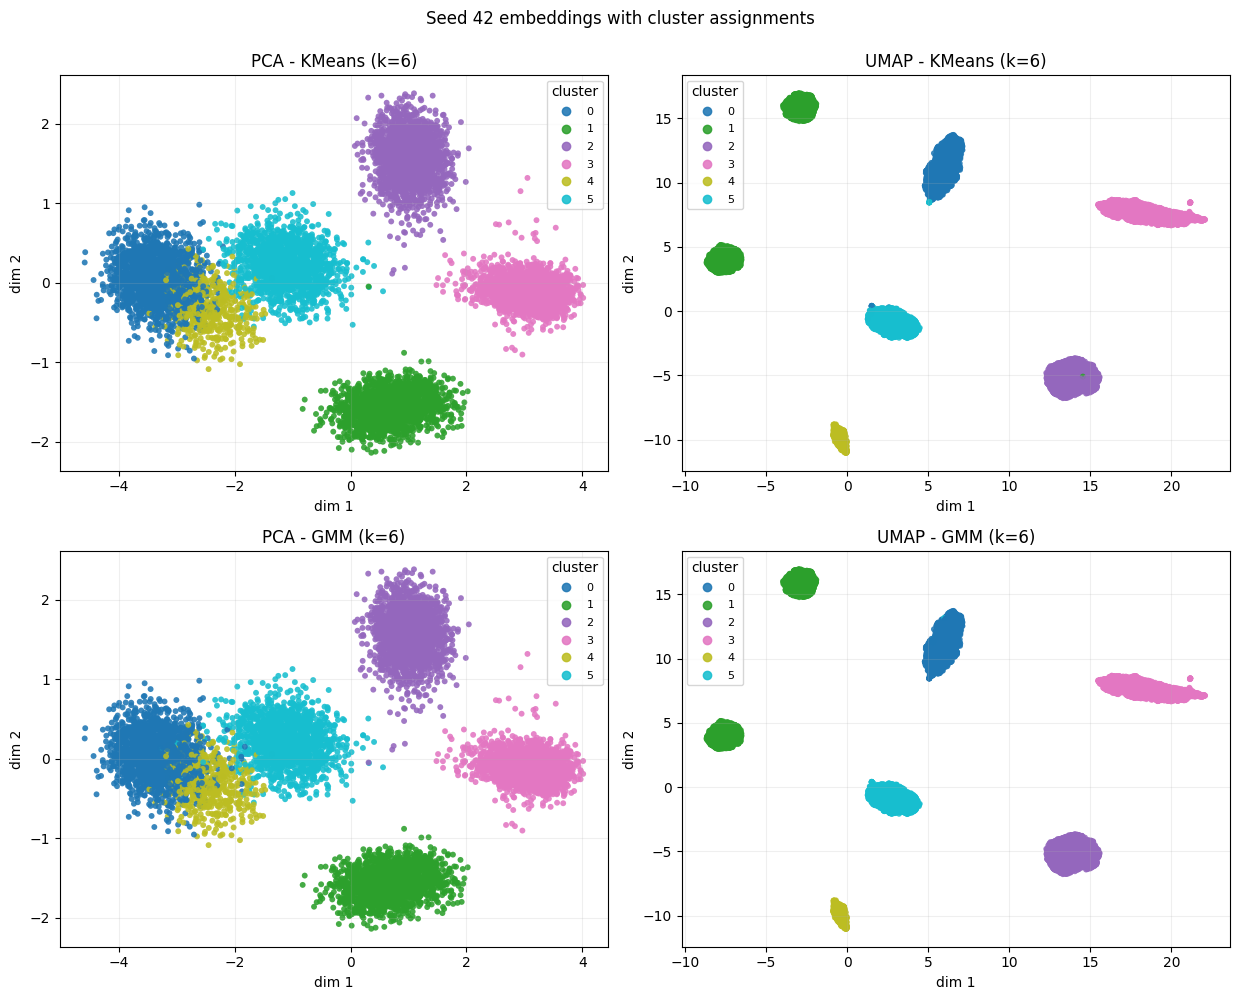

In [11]:
pca = PCA(n_components=2)
pca_embedding = pca.fit_transform(X)

umap_available = False
umap_embedding = pca_embedding.copy()
try:
    import umap  # type: ignore[import-not-found]
    reducer = umap.UMAP(random_state=42)
    umap_embedding = reducer.fit_transform(X)
    umap_available = True
except Exception:
    umap_available = False

print(f'PCA explained variance ratio (PC1+PC2): {pca.explained_variance_ratio_.sum():.4f}')
print(f'UMAP available: {umap_available}')


def plot_embedding_panel(ax, emb, labels, title):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=18, alpha=0.88, edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    ax.grid(alpha=0.2)
    ax.legend(*scatter.legend_elements(), title='cluster', loc='best', fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(12.5, 10))
plot_embedding_panel(axes[0, 0], pca_embedding, kmeans_assignments[selected_kmeans], f'PCA - KMeans (k={selected_kmeans})')
plot_embedding_panel(axes[0, 1], umap_embedding, kmeans_assignments[selected_kmeans], f'UMAP - KMeans (k={selected_kmeans})')
plot_embedding_panel(axes[1, 0], pca_embedding, gmm_assignments[selected_gmm], f'PCA - GMM (k={selected_gmm})')
plot_embedding_panel(axes[1, 1], umap_embedding, gmm_assignments[selected_gmm], f'UMAP - GMM (k={selected_gmm})')
fig.suptitle('Seed 42 embeddings with cluster assignments', y=0.995)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_embeddings_seed42.png', dpi=200, bbox_inches='tight')
plt.show()

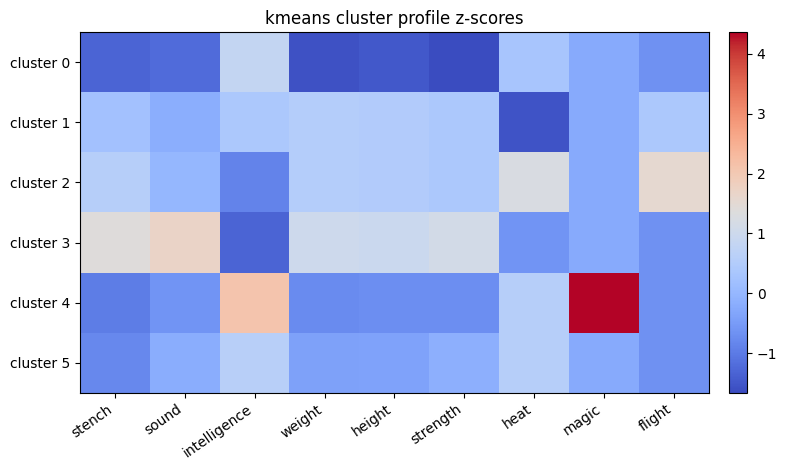

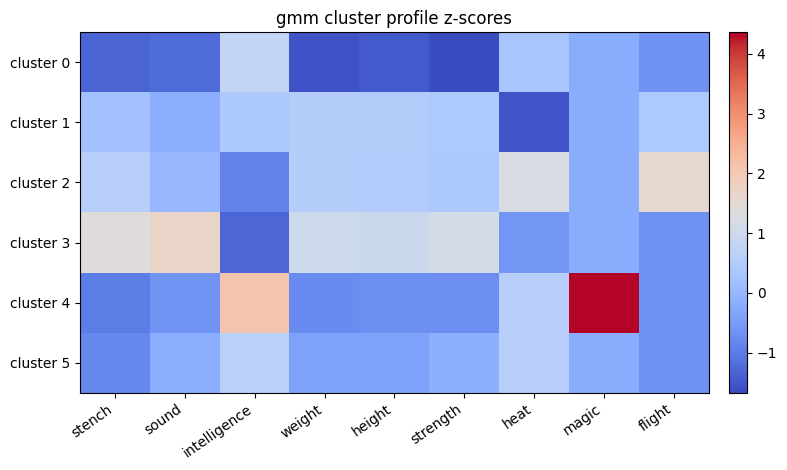

In [12]:
def plot_profile_heatmap(profile_df: pd.DataFrame, method: str):
    z_cols = [c for c in profile_df.columns if c.startswith('z_')]
    feature_names = [c.replace('z_', '') for c in z_cols]
    matrix = profile_df[z_cols].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(max(8, len(feature_names) * 0.85), 4.8))
    im = ax.imshow(matrix, aspect='auto', cmap='coolwarm')
    ax.set_xticks(np.arange(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=35, ha='right')
    ax.set_yticks(np.arange(len(profile_df)))
    ax.set_yticklabels([f'cluster {int(c)}' for c in profile_df['cluster']])
    ax.set_title(f'{method} cluster profile z-scores')
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    fig.tight_layout()
    return fig

fig1 = plot_profile_heatmap(kmeans_profile, 'kmeans')
fig1.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_kmeans_profile_seed42.png', dpi=200, bbox_inches='tight')
plt.show()

fig2 = plot_profile_heatmap(gmm_profile, 'gmm')
fig2.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_gmm_profile_seed42.png', dpi=200, bbox_inches='tight')
plt.show()

## Evaluation and Comparison

Internal metrics drive the main comparison. Silhouette captures compactness and separation, Davies-Bouldin penalizes overlapping or diffuse clusters, and Calinski-Harabasz rewards good between-cluster versus within-cluster scatter. Because hidden species labels are available, I also report ARI and NMI as post-hoc checks, not as training objectives.

The main pattern is that both methods consistently prefer `k=6` in the method-best view, even though there are five known species. That is not a contradiction. Unsupervised structure does not have to align one-to-one with semantic labels.

In [13]:
seed_list = [42, 123, 2026]
frames = []
for seed in seed_list:
    df = pd.read_csv(OUTPUTS_DIR / 'tables' / f'metrics_compare_seed{seed}.csv')
    df['seed'] = seed
    frames.append(df)

multi_seed_df = pd.concat(frames, ignore_index=True)
multi_seed_summary = (
    multi_seed_df.groupby(['view', 'method'])
    .agg(
        silhouette_mean=('silhouette', 'mean'),
        silhouette_std=('silhouette', 'std'),
        davies_bouldin_mean=('davies_bouldin', 'mean'),
        davies_bouldin_std=('davies_bouldin', 'std'),
        calinski_harabasz_mean=('calinski_harabasz', 'mean'),
        calinski_harabasz_std=('calinski_harabasz', 'std'),
        fit_seconds_mean=('fit_seconds', 'mean'),
        fit_seconds_std=('fit_seconds', 'std'),
        ari_mean=('ari', 'mean'),
        nmi_mean=('nmi', 'mean'),
    )
    .reset_index()
)
multi_seed_summary[['silhouette_std', 'davies_bouldin_std', 'calinski_harabasz_std', 'fit_seconds_std']] = multi_seed_summary[['silhouette_std', 'davies_bouldin_std', 'calinski_harabasz_std', 'fit_seconds_std']].fillna(0.0)
display(multi_seed_summary.round(6))

,view,method,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,fit_seconds_mean,fit_seconds_std,ari_mean,nmi_mean
0,fixed_same_k,gmm,0.557080,0.0,0.738137,0.0,16726.066486,0.0,0.131866,0.013444,0.994511,0.990662
1,fixed_same_k,kmeans,0.557785,0.0,0.735717,0.0,16845.798894,0.0,0.046672,0.002619,0.985178,0.979462
2,method_best,gmm,0.566270,0.0,0.713580,0.0,16193.071270,0.0,0.186043,0.063892,0.946883,0.958154
3,method_best,kmeans,0.567111,0.0,0.710041,0.0,16317.844396,0.0,0.049319,0.002269,0.946035,0.956407


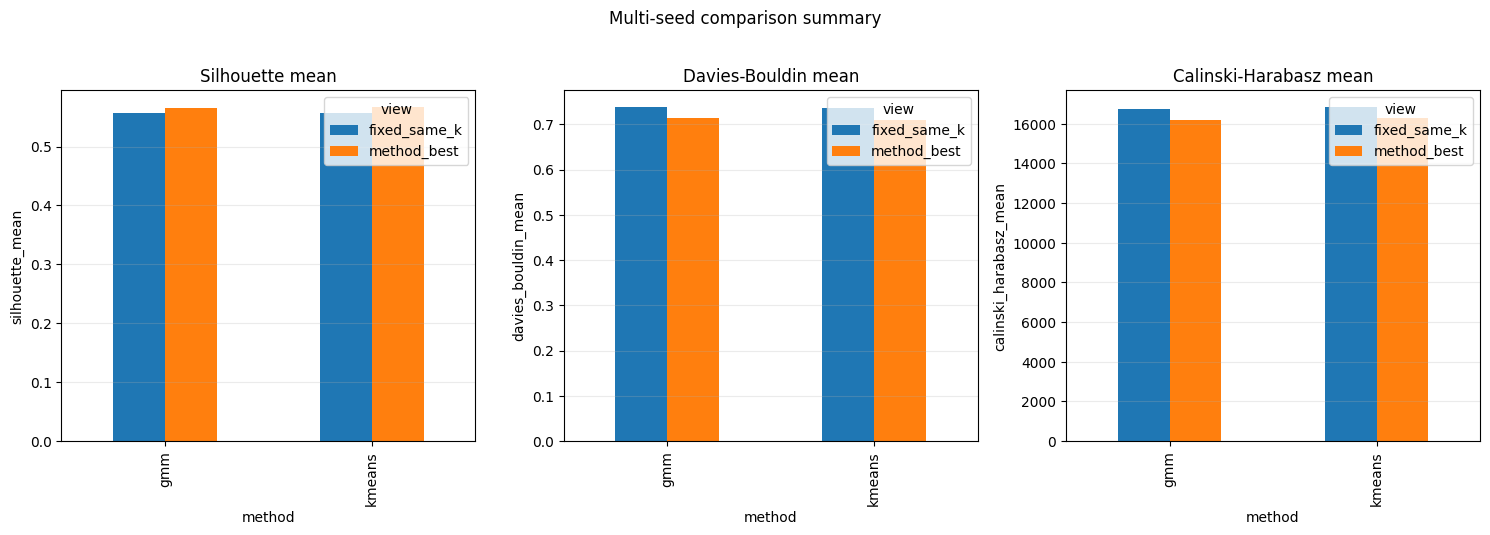

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, metric, label in [
    (axes[0], 'silhouette_mean', 'Silhouette mean'),
    (axes[1], 'davies_bouldin_mean', 'Davies-Bouldin mean'),
    (axes[2], 'calinski_harabasz_mean', 'Calinski-Harabasz mean'),
]:
    pivot = multi_seed_summary.pivot(index='method', columns='view', values=metric)
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(label)
    ax.set_xlabel('method')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Multi-seed comparison summary', y=1.02)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'figures' / 'task2_report_multi_seed_summary.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
# The high-risk feature 'bribe' is kept out of the main report, but this sensitivity check
# shows how much it inflates apparent cluster separability.
main_summary = pd.read_csv(OUTPUTS_DIR / 'tables' / 'metrics_multi_seed_summary.csv')
bribe_summary = pd.read_csv(BRIBE_OUTPUTS_DIR / 'tables' / 'metrics_multi_seed_summary.csv')

display(main_summary)
display(bribe_summary)

,view,method,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,fit_seconds_mean,fit_seconds_std
0,fixed_same_k,gmm,0.557080,0.0,0.738137,0.000000e+00,16726.066486,0.000000e+00,0.131866,0.013444
1,fixed_same_k,kmeans,0.557785,0.0,0.735717,1.359740e-16,16845.798894,2.572439e-12,0.046672,0.002619
2,method_best,gmm,0.566270,0.0,0.713580,1.110223e-16,16193.071270,6.301164e-12,0.186043,0.063892
3,method_best,kmeans,0.567111,0.0,0.710041,7.850462e-17,16317.844396,0.000000e+00,0.049319,0.002269


,view,method,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,fit_seconds_mean,fit_seconds_std
0,fixed_same_k,gmm,0.614112,0.0,0.606102,7.850462e-17,17656.971810,2.572439e-12,0.119874,0.002466
1,fixed_same_k,kmeans,0.614243,0.0,0.605794,0.000000e+00,17686.679093,0.000000e+00,0.035287,0.001671
2,method_best,gmm,0.617457,0.0,0.615357,7.850462e-17,18441.596795,0.000000e+00,0.179841,0.022170
3,method_best,kmeans,0.617575,0.0,0.615553,7.850462e-17,18477.571511,0.000000e+00,0.044588,0.002109


## Self-Reflection and Limitations

This workflow is intentionally conservative, but it still has clear limits.

- Unsupervised evaluation is intrinsically harder than supervised evaluation. Internal metrics help, but they do not fully capture semantic usefulness.
- K-Means is sensitive to initialization and to the assumption of roughly spherical clusters.
- GMM is more flexible, but also more expensive and more sensitive to covariance conditioning.
- External labels are only used after fitting, so ARI and NMI should be read as validation aids, not as optimization targets.
- The `bribe` feature is a useful warning sign: it can make clusters look better very quickly, so it belongs in sensitivity analysis rather than the main evidence stream.

## Summary

The main conclusion is that both K-Means and GMM recover a very similar latent structure in the sensor statistics. Under the project selection rule, both methods prefer six clusters. K-Means is slightly better on the core internal scores and faster, while GMM provides soft membership and nearly matches the external alignment with hidden species labels.

So the data really does contain a discoverable structure, but the structure is not perfectly identical to the semantic species names. That is exactly what makes this a good unsupervised learning exercise.

## References

[1] scikit-learn developers. *KMeans* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

[2] scikit-learn developers. *GaussianMixture* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

[3] scikit-learn developers. *PCA* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

[4] Leland McInnes, John Healy, and James Melville. *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* arXiv:1802.03426. https://arxiv.org/abs/1802.03426